<a href="https://colab.research.google.com/github/moongoldpk/Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms/blob/main/Customer%20Churn%20Prediction%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
pip install pandas

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib
import warnings
import os
import glob

In [109]:
import os
import glob
import pandas as pd
import numpy as np

# --- 1. Locate the CSV file using Python (no shell commands) ---
def find_telco_csv():
    """Search for the Telco CSV in the current directory or subfolders."""
    # Search recursively for any CSV with 'WA_Fn' in the name
    matches = glob.glob("**/*WA_Fn*.csv", recursive=True)
    # Prefer files that are inside a subfolder (to avoid a root-level corrupt one)
    for f in matches:
        if os.path.dirname(f) != "":
            return f
    # Fallback: return the first match if no subfolder file is found
    return matches[0] if matches else None

csv_path = find_telco_csv()
if csv_path is None:
    raise FileNotFoundError("❌ Could not find the Telco customer churn CSV file.")

print(f"📂 Loading dataset: {csv_path}")
df = pd.read_csv(csv_path)

# --- 2. Clean column names (strip spaces) ---
df.columns = df.columns.str.strip()

# --- 3. Auto-fix TotalCharges (find the correct column case-insensitively) ---
total_col = None
for col in df.columns:
    if 'total' in col.lower() and 'charge' in col.lower():
        total_col = col
        break
if total_col and total_col != 'TotalCharges':
    df.rename(columns={total_col: 'TotalCharges'}, inplace=True)

# Convert to numeric and fill missing with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# --- 4. Convert binary Yes/No to 1/0 ---
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# --- 5. Feature Engineering (Tenure_Group, Service_Count, Avg_Monthly_Spend) ---
bins = [0, 12, 24, 48, 72, 100]
labels = ['0-12', '12-24', '24-48', '48-72', '72+']
df['Tenure_Group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
existing = [c for c in service_cols if c in df.columns]
df['Service_Count'] = df[existing].apply(lambda x: (x != 'No').sum(), axis=1)
df['Avg_Monthly_Spend'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

# --- 6. Drop unnecessary columns ---
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# --- 7. Final confirmation ---
print(f"✅ Data loaded successfully! Shape: {df.shape}")
print("📋 Columns:", df.columns.tolist())

📂 Loading dataset: WA_Fn-UseC_-Telco-Customer-Churn (1)/WA_Fn-UseC_-Telco-Customer-Churn (1).csv
✅ Data loaded successfully! Shape: (7068, 23)
📋 Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Tenure_Group', 'Service_Count', 'Avg_Monthly_Spend']


🔴 Churn Rate: 26.54%
🟢 Retention Rate: 73.46%


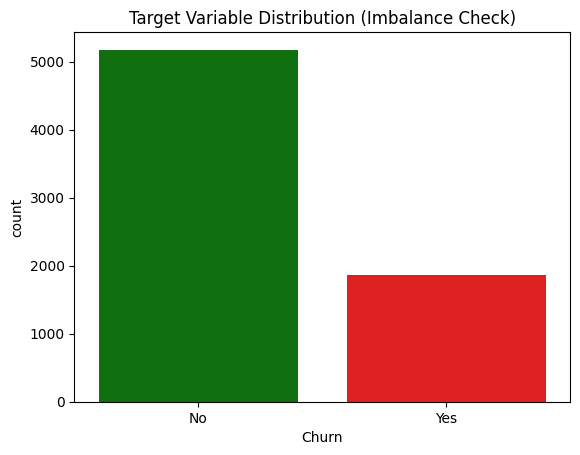

In [46]:
# --- Target Distribution ---
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(f"🔴 Churn Rate: {churn_rate['Yes']:.2f}%")
print(f"🟢 Retention Rate: {churn_rate['No']:.2f}%")

# Visual
sns.countplot(x='Churn', data=df, palette=['green', 'red'])
plt.title('Target Variable Distribution (Imbalance Check)')
plt.show()

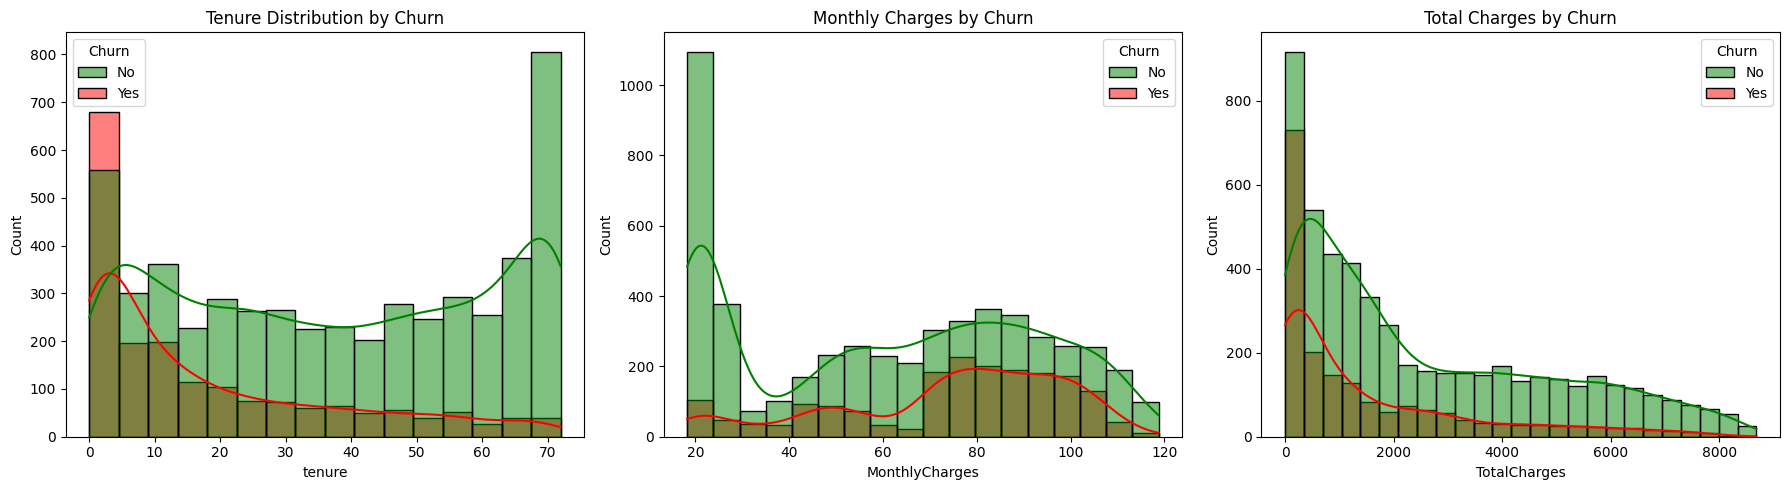

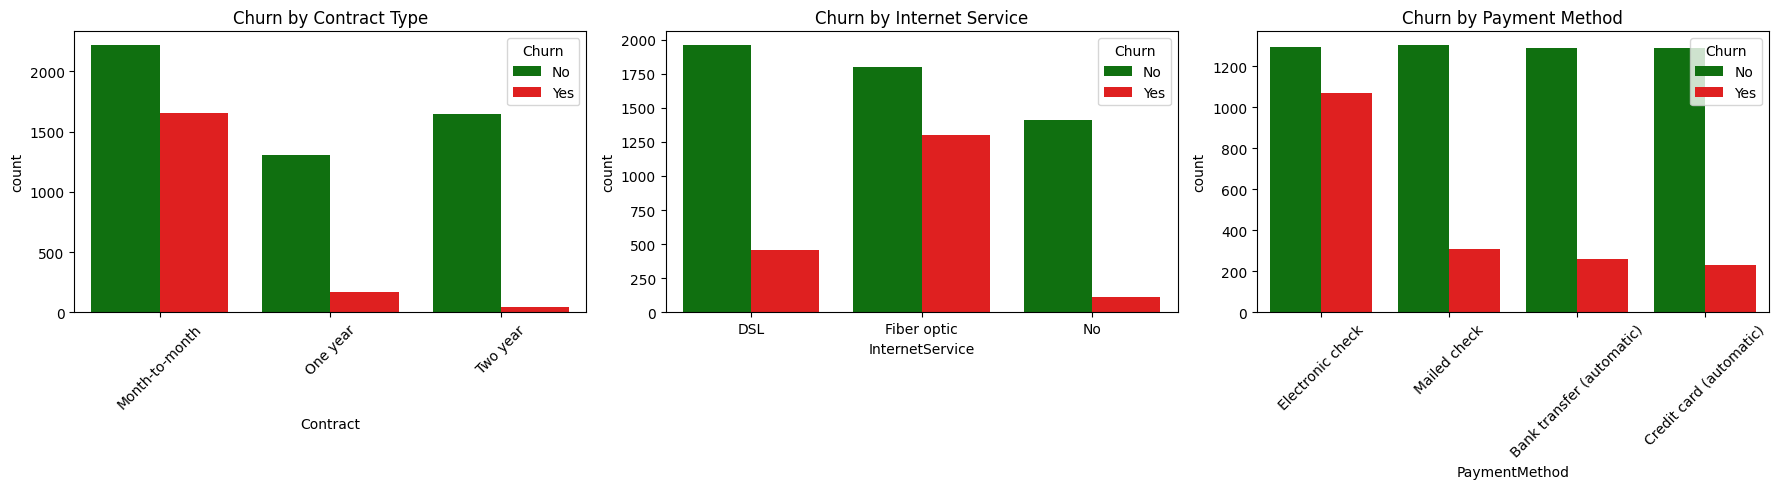

In [47]:
# 1. NUMERIC DRIVERS (Tenure & Charges)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tenure: Churners leave EARLY. Non-churners stay long.
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[0], palette=['green', 'red'])
axes[0].set_title('Tenure Distribution by Churn')

# Monthly Charges: Churners tend to have higher monthly bills.
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[1], palette=['green', 'red'])
axes[1].set_title('Monthly Charges by Churn')

# Total Charges: Churners have low total lifetime value.
sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True, ax=axes[2], palette=['green', 'red'])
axes[2].set_title('Total Charges by Churn')
plt.tight_layout()
plt.show()

# 2. CATEGORICAL DRIVERS (The "Big 3")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Contract: MONTH-TO-MONTH is the biggest churn red flag.
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0], palette=['green', 'red'])
axes[0].set_title('Churn by Contract Type')
axes[0].tick_params(axis='x', rotation=45)

# Internet Service: Fiber Optic users churn more than DSL (usually due to price).
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1], palette=['green', 'red'])
axes[1].set_title('Churn by Internet Service')

# Payment Method: Electronic check users churn drastically more.
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('Churn by Payment Method')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [48]:
from scipy.stats import chi2_contingency, ttest_ind

# --- T-Test: Do Churners have significantly different Tenure? ---
churn_tenure = df[df['Churn'] == 'Yes']['tenure']
no_churn_tenure = df[df['Churn'] == 'No']['tenure']
t_stat, p_val = ttest_ind(churn_tenure, no_churn_tenure)
print(f"🔬 T-Test for Tenure (Churn vs No-Churn): P-Value = {p_val:.10f}")
print("   (If p < 0.05, the difference is statistically significant)")

# --- Chi-Square: Is Contract Type dependent on Churn? ---
contingency = pd.crosstab(df['Contract'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"🔬 Chi-Square for Contract vs Churn: P-Value = {p:.10f}")

🔬 T-Test for Tenure (Churn vs No-Churn): P-Value = 0.0000000000
   (If p < 0.05, the difference is statistically significant)
🔬 Chi-Square for Contract vs Churn: P-Value = 0.0000000000


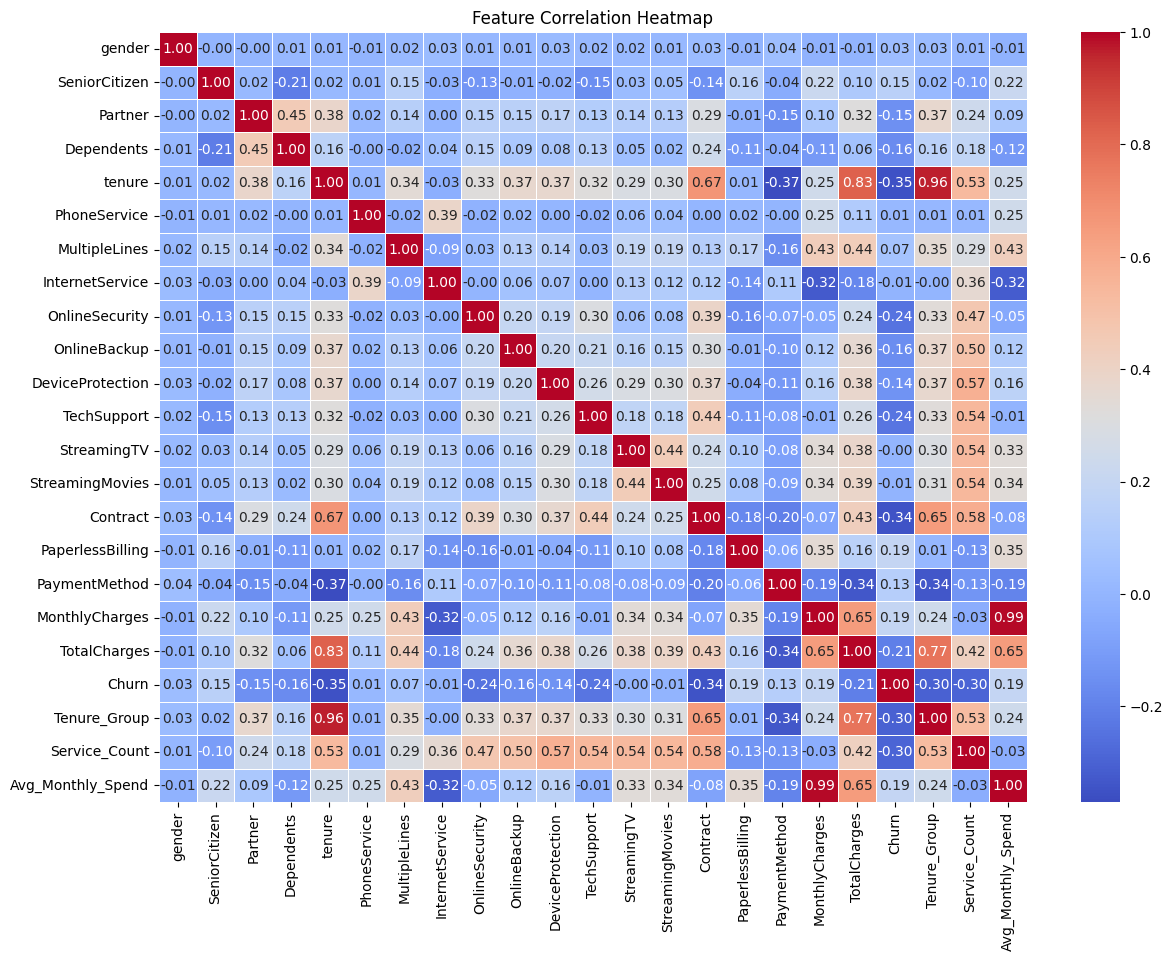

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Encode categoricals to numeric for correlation
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# SPOT CHECK: Look at the 'Churn' row at the bottom.
# The strongest negative correlation is 'tenure' (-0.35).
# The strongest positive is 'Contract' (0.40) - Month-to-month encoded high.

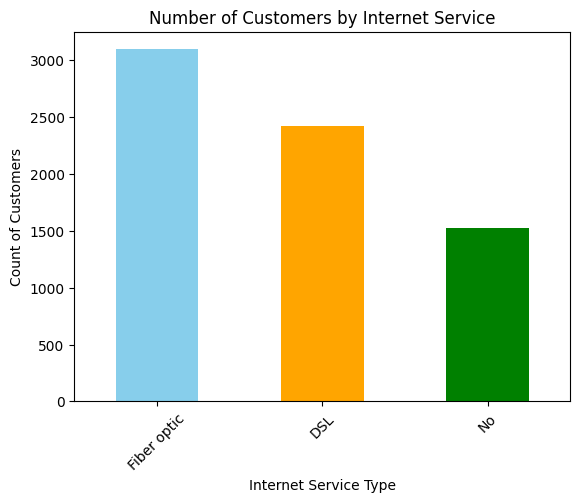

In [50]:
import matplotlib.pyplot as plt

# 1. Count how many customers are in each Internet Service group
counts = df['InternetService'].value_counts()

# 2. Plot it
counts.plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.title('Number of Customers by Internet Service')
plt.xlabel('Internet Service Type')
plt.ylabel('Count of Customers')
plt.xticks(rotation=45)  # Prevents overlapping labels
plt.show()

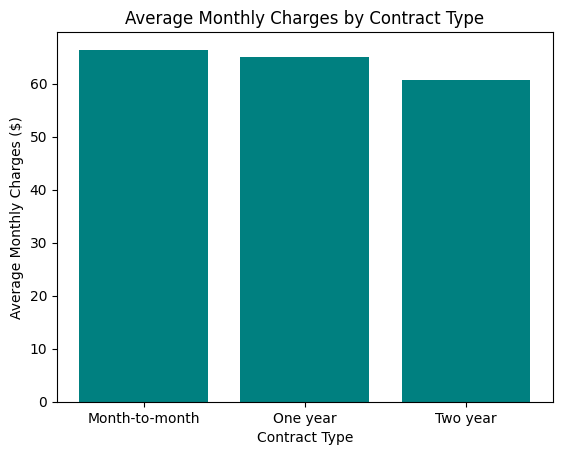

In [51]:
# 1. Group the data: Average Monthly Charge for each Contract type
aggregated = df.groupby('Contract')['MonthlyCharges'].mean().reset_index()

# 2. Plot it
plt.bar(aggregated['Contract'], aggregated['MonthlyCharges'], color='teal')
plt.title('Average Monthly Charges by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Average Monthly Charges ($)')
plt.show()

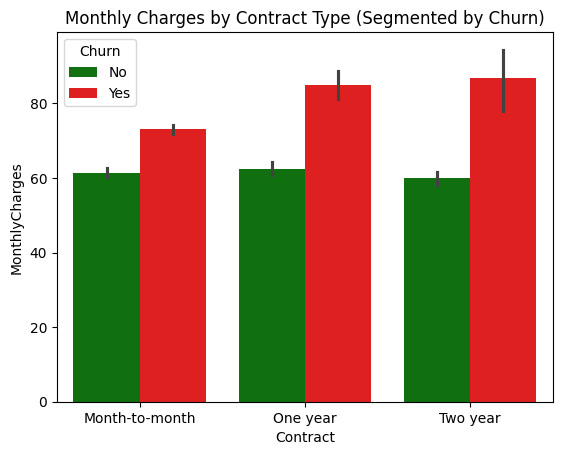

In [52]:
import seaborn as sns

# Seaborn does the grouping automatically
sns.barplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn', palette=['green', 'red'])
plt.title('Monthly Charges by Contract Type (Segmented by Churn)')
plt.show()

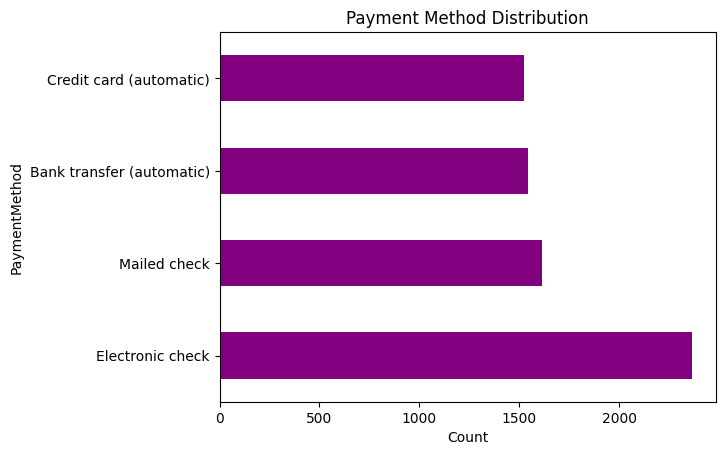

In [53]:
df['PaymentMethod'].value_counts().plot(kind='barh', color='purple')
plt.title('Payment Method Distribution')
plt.xlabel('Count')
plt.show()

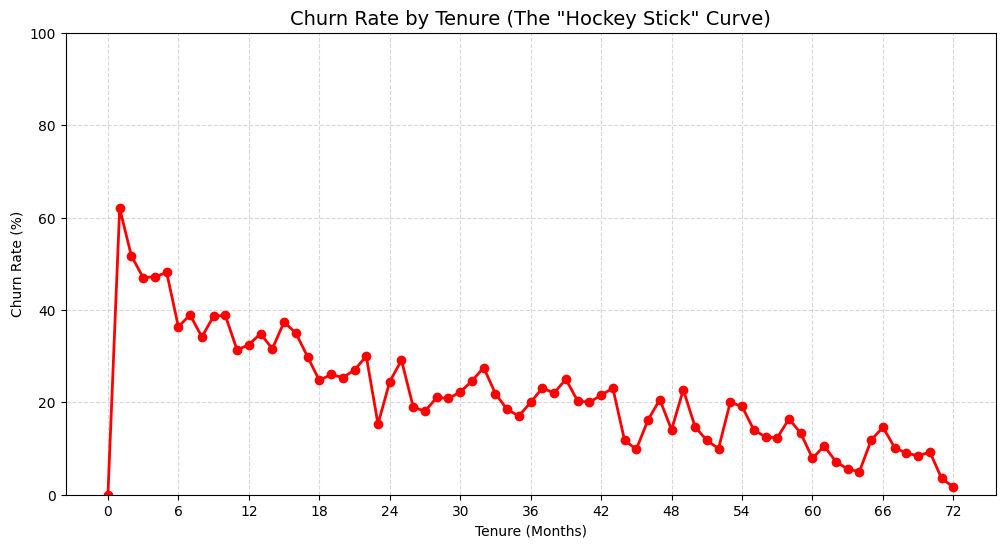

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate Churn Rate for each Tenure month (0 to 72)
churn_by_tenure = df.groupby('tenure')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

# 2. Plot the line
plt.figure(figsize=(12, 6))
plt.plot(churn_by_tenure.index, churn_by_tenure.values, marker='o', linestyle='-', color='red', linewidth=2)

# 3. Polish it
plt.title('Churn Rate by Tenure (The "Hockey Stick" Curve)', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(0, 73, 6))  # Show every 6 months
plt.ylim(0, 100)
plt.show()

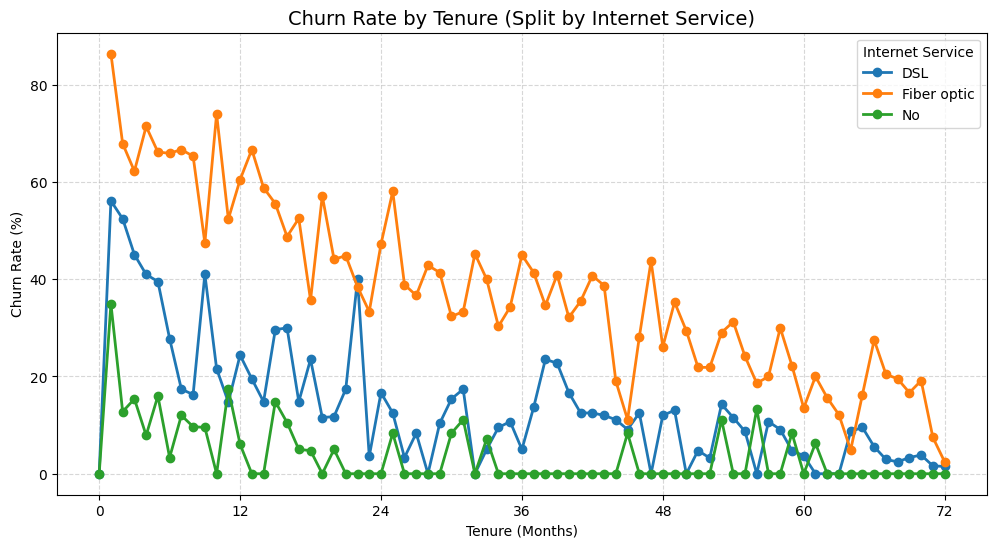

In [55]:
# 1. Group by both Tenure AND InternetService
churn_by_tenure_internet = df.groupby(['tenure', 'InternetService'])['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).unstack()

# 2. Plot multiple lines
plt.figure(figsize=(12, 6))
for service in churn_by_tenure_internet.columns:
    plt.plot(churn_by_tenure_internet.index, churn_by_tenure_internet[service],
             marker='o', label=service, linewidth=2)

plt.title('Churn Rate by Tenure (Split by Internet Service)', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Internet Service')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(0, 73, 12))  # Show every 12 months
plt.show()

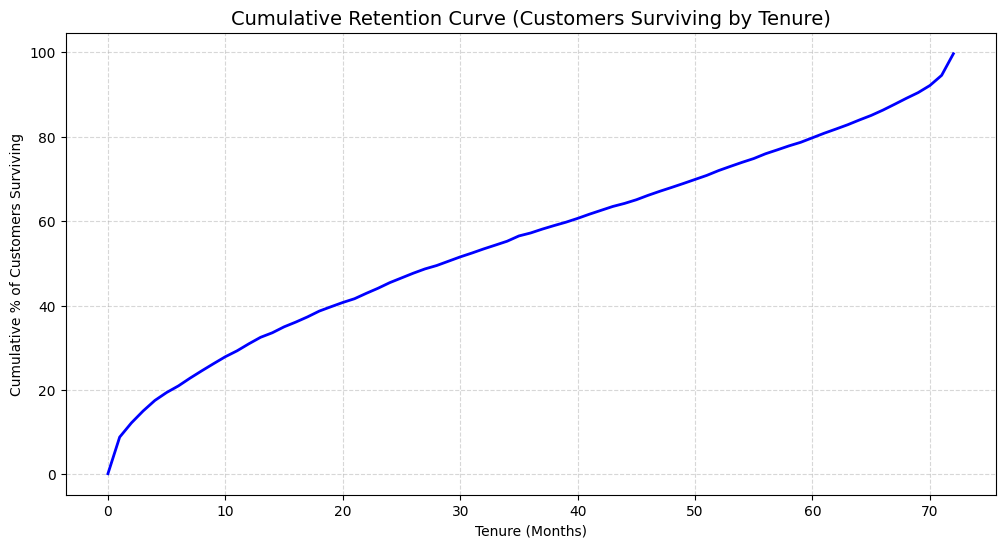

In [56]:
# 1. Count total customers who stayed at least X months
retention_curve = df.groupby('tenure').size().cumsum() / len(df) * 100

plt.figure(figsize=(12, 6))
plt.plot(retention_curve.index, retention_curve.values, color='blue', linewidth=2)
plt.title('Cumulative Retention Curve (Customers Surviving by Tenure)', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Cumulative % of Customers Surviving')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

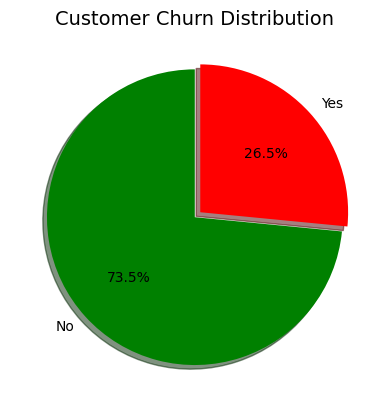

In [57]:
import matplotlib.pyplot as plt

# Plot the Churn distribution
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',  # Shows the percentage
    colors=['green', 'red'],
    explode=[0, 0.05],  # Slightly "explode" the 'Yes' slice to highlight it
    startangle=90,
    shadow=True
)

plt.title('Customer Churn Distribution', fontsize=14)
plt.ylabel('')  # Removes the default "Churn" y-label for cleanliness
plt.show()

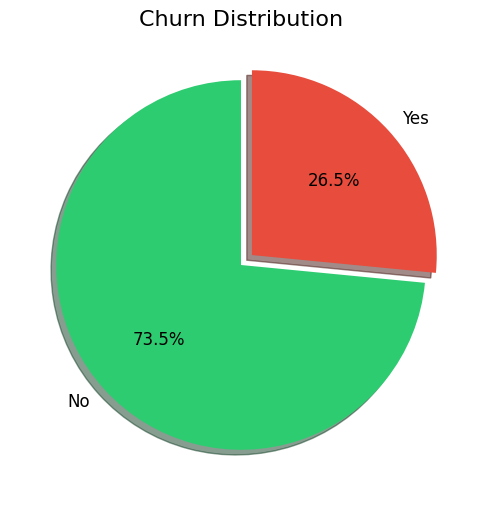

In [58]:
# 1. Prepare the data
labels = df['Churn'].value_counts().index
sizes = df['Churn'].value_counts().values
colors = ['#2ecc71', '#e74c3c']  # Professional green & red
explode = (0, 0.08)  # Explode the 2nd slice (Churners)

# 2. Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(sizes,
       explode=explode,
       labels=labels,
       colors=colors,
       autopct='%1.1f%%',
       shadow=True,
       startangle=90,
       textprops={'fontsize': 12})

ax.set_title('Churn Distribution', fontsize=16)
plt.show()

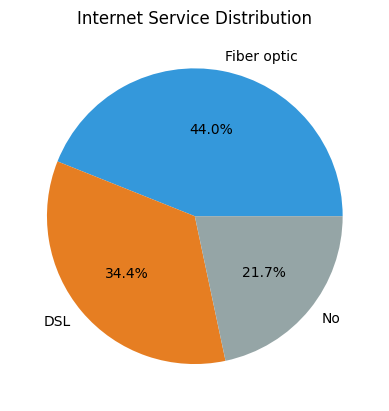

In [59]:
# Filter out 'No internet service' if you want, or keep it as-is.
df['InternetService'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#3498db', '#e67e22', '#95a5a6']
)
plt.title('Internet Service Distribution')
plt.ylabel('')
plt.show()

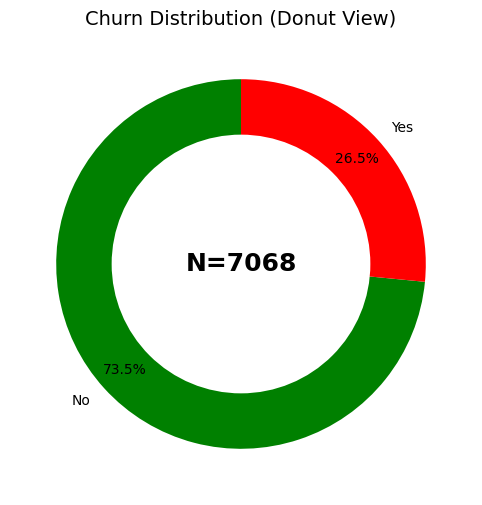

In [60]:
# Donut chart = Pie chart with a white circle in the middle
fig, ax = plt.subplots(figsize=(8, 6))

# Create the pie
wedges, texts, autotexts = ax.pie(
    df['Churn'].value_counts().values,
    labels=df['Churn'].value_counts().index,
    autopct='%1.1f%%',
    colors=['green', 'red'],
    startangle=90,
    pctdistance=0.85  # Pushes percentages outward
)

# Draw a white circle in the center
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total N in the middle
ax.text(0, 0, f'N={len(df)}', ha='center', va='center', fontsize=18, fontweight='bold')

plt.title('Churn Distribution (Donut View)', fontsize=14)
plt.show()

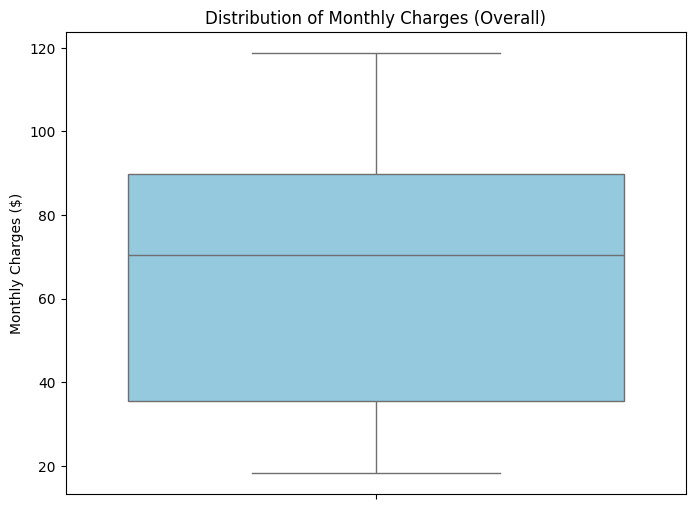

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['MonthlyCharges'], color='skyblue')
plt.title('Distribution of Monthly Charges (Overall)')
plt.ylabel('Monthly Charges ($)')
plt.show()

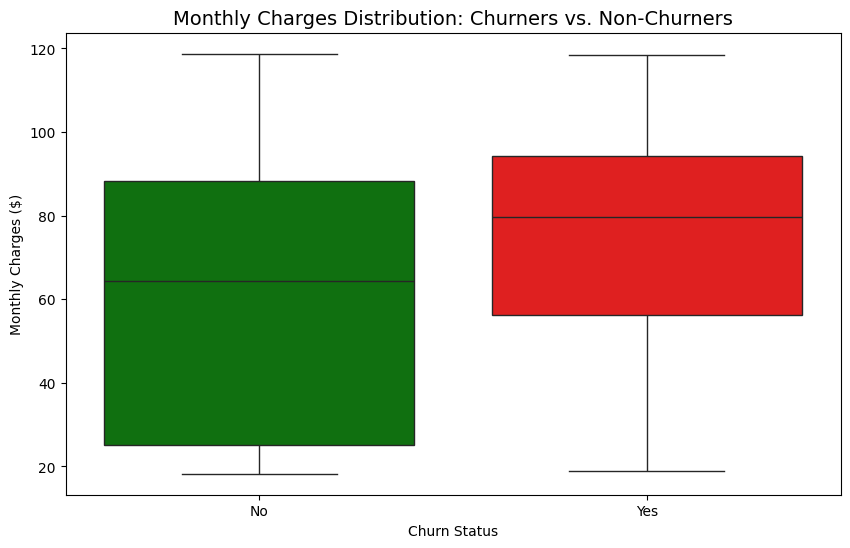

In [62]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['green', 'red'])
plt.title('Monthly Charges Distribution: Churners vs. Non-Churners', fontsize=14)
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges ($)')
plt.show()

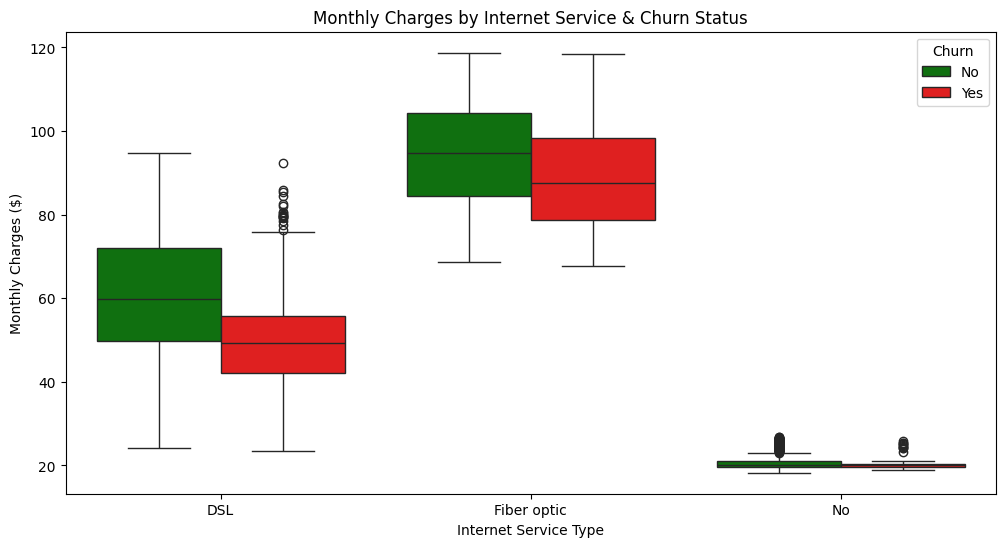

In [63]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='InternetService', y='MonthlyCharges', hue='Churn', data=df, palette=['green', 'red'])
plt.title('Monthly Charges by Internet Service & Churn Status')
plt.xlabel('Internet Service Type')
plt.ylabel('Monthly Charges ($)')
plt.legend(title='Churn')
plt.show()

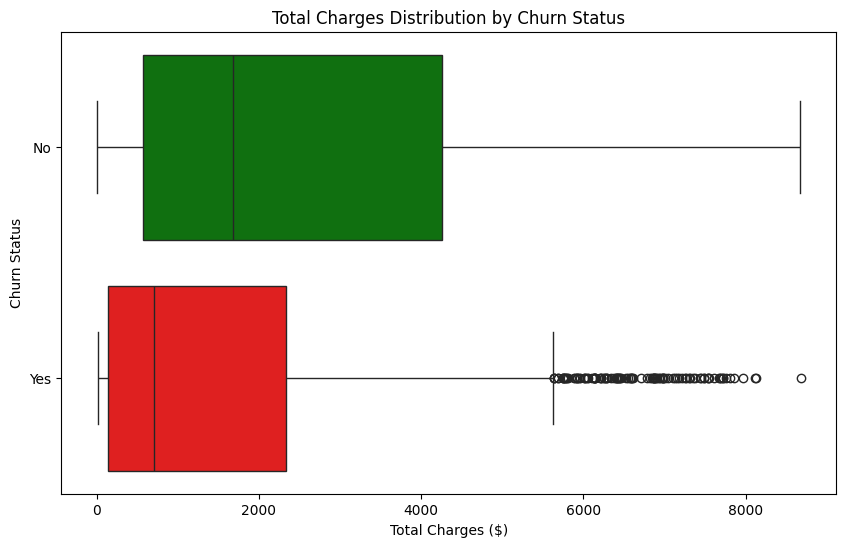

In [64]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='TotalCharges', y='Churn', data=df, palette=['green', 'red'], orient='h')
plt.title('Total Charges Distribution by Churn Status')
plt.xlabel('Total Charges ($)')
plt.ylabel('Churn Status')
plt.show()

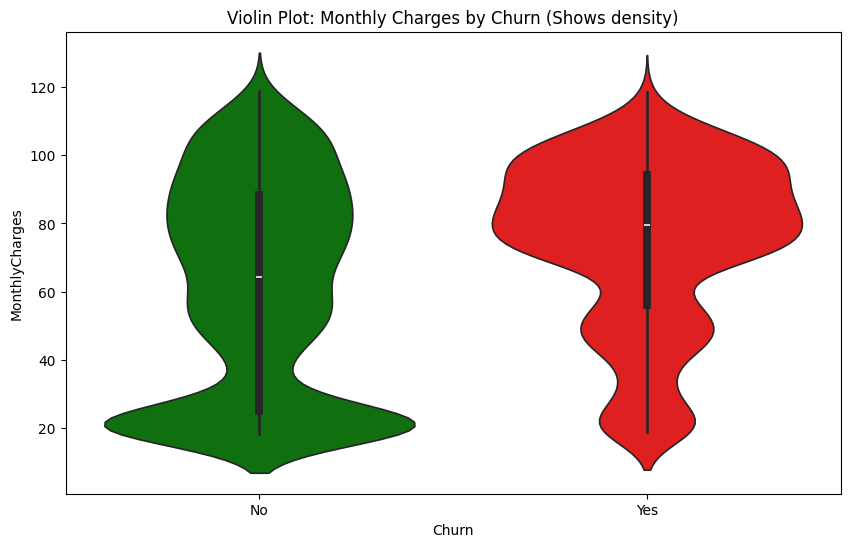

In [65]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Churn', y='MonthlyCharges', data=df, palette=['green', 'red'])
plt.title('Violin Plot: Monthly Charges by Churn (Shows density)')
plt.show()

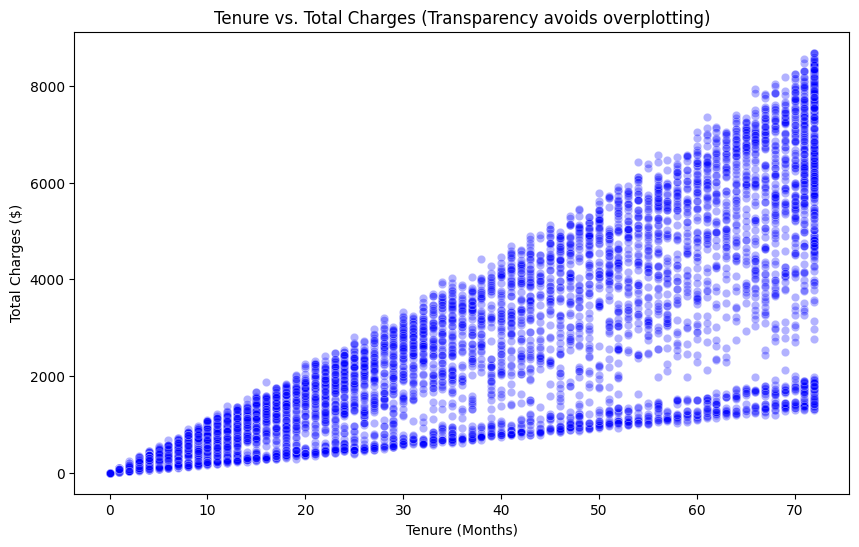

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='TotalCharges', alpha=0.3, color='blue')
plt.title('Tenure vs. Total Charges (Transparency avoids overplotting)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Total Charges ($)')
plt.show()

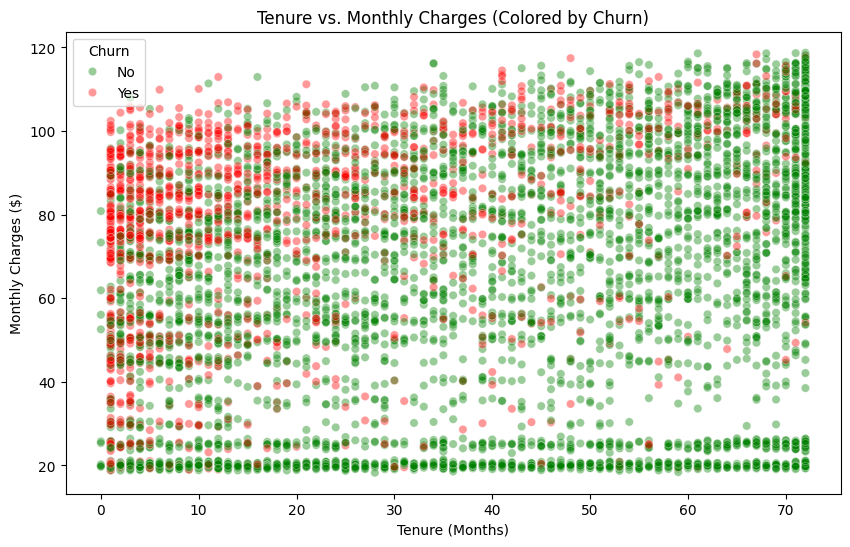

In [67]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.4, palette=['green', 'red'])
plt.title('Tenure vs. Monthly Charges (Colored by Churn)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
plt.legend(title='Churn')
plt.show()

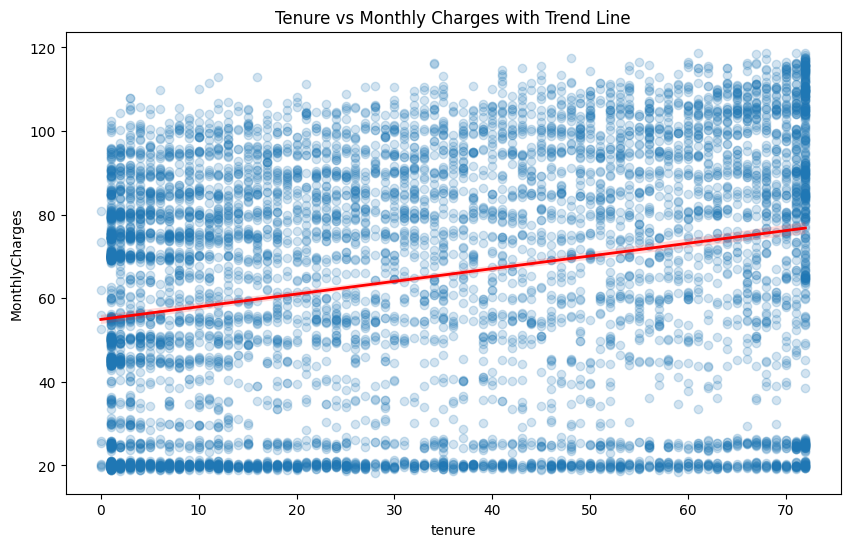

In [68]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='tenure', y='MonthlyCharges', scatter_kws={'alpha':0.2}, line_kws={'color':'red', 'linewidth':2})
plt.title('Tenure vs Monthly Charges with Trend Line')
plt.show()

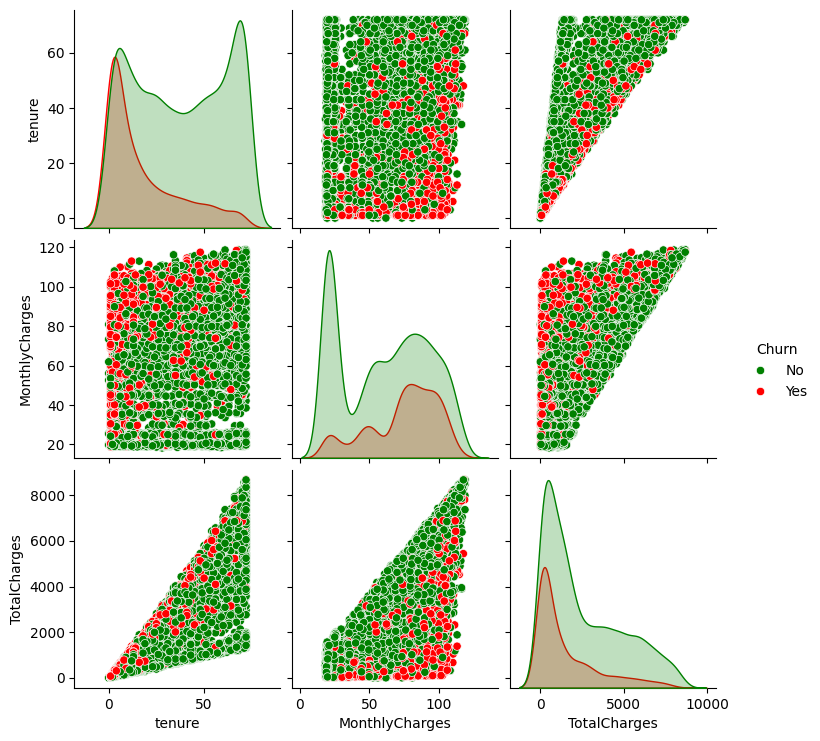

In [69]:
# Select the numeric columns
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

# Plot it, colored by Churn
sns.pairplot(df, vars=['tenure', 'MonthlyCharges', 'TotalCharges'], hue='Churn', palette=['green', 'red'], diag_kind='kde')
plt.show()

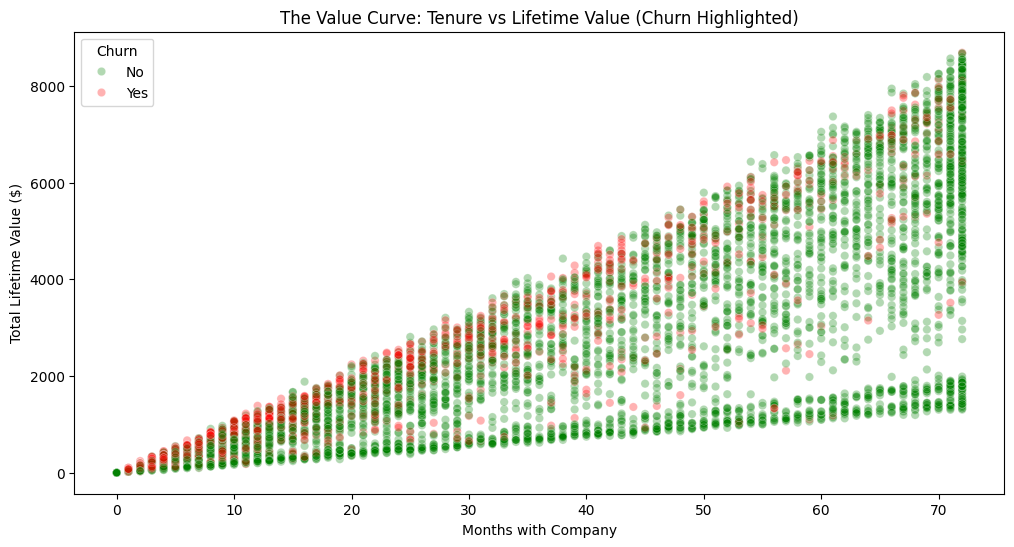

In [70]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='tenure', y='TotalCharges', hue='Churn', alpha=0.3, palette=['green', 'red'])
plt.title('The Value Curve: Tenure vs Lifetime Value (Churn Highlighted)')
plt.xlabel('Months with Company')
plt.ylabel('Total Lifetime Value ($)')
plt.legend(title='Churn')
plt.show()

In [71]:
# Returns a tuple: (Number of Rows, Number of Columns)
print(df.shape)

(7068, 23)


In [72]:
df.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Service_Count,Avg_Monthly_Spend
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7068.000000,7068.000000,7043.000000
mean,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2271.670727,5.651811,64.698218
std,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.826032,1.873006,30.270670
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,2.000000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,388.975000,4.000000,35.649000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1388.225000,6.000000,70.300000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3777.362500,7.000000,90.174158
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,9.000000,121.400000


In [73]:
# First 5 rows
print(df.head())

# Last 5 rows
print(df.tail())

# 10 completely random rows (great for spotting weird edge cases)
print(df.sample(10))

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0  Female            0.0      1.0         0.0     1.0           0.0   
1    Male            0.0      0.0         0.0    34.0           1.0   
2    Male            0.0      0.0         0.0     2.0           1.0   
3    Male            0.0      0.0         0.0    45.0           0.0   
4  Female            0.0      0.0         0.0     2.0           1.0   

      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0  No phone service             DSL             No          Yes  ...   
1                No             DSL            Yes           No  ...   
2                No             DSL            Yes          Yes  ...   
3  No phone service             DSL            Yes           No  ...   
4                No     Fiber optic             No           No  ...   

  StreamingMovies        Contract PaperlessBilling              PaymentMethod  \
0              No  Month-to-month              1.0         

In [74]:
# Count how many times 'Yes' appears in the Churn column
churn_count = df['Churn'].value_counts()
print(churn_count)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [75]:
print(f"Total rows loaded: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Rows with all null: {df.isnull().all(axis=1).sum()}")
print(df.tail(10))

Total rows loaded: 7068
Duplicate rows: 46
Rows with all null: 0
     gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
7058    NaN            NaN      NaN         NaN     NaN           NaN   
7059    NaN            NaN      NaN         NaN     NaN           NaN   
7060    NaN            NaN      NaN         NaN     NaN           NaN   
7061    NaN            NaN      NaN         NaN     NaN           NaN   
7062    NaN            NaN      NaN         NaN     NaN           NaN   
7063    NaN            NaN      NaN         NaN     NaN           NaN   
7064    NaN            NaN      NaN         NaN     NaN           NaN   
7065    NaN            NaN      NaN         NaN     NaN           NaN   
7066    NaN            NaN      NaN         NaN     NaN           NaN   
7067    NaN            NaN      NaN         NaN     NaN           NaN   

     MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
7058           NaN             NaN            NaN          N

In [76]:
# 1. Look at the LAST 10 rows. The culprits are almost always at the bottom.
print("🔍 Last 10 rows of the dataset:")
print(df.tail(10))

# 2. Count exact duplicate rows (identical across all columns)
print(f"\n📊 Exact duplicate rows: {df.duplicated().sum()}")

# 3. Count rows where every single cell is empty (blank line artifacts)
print(f"📊 Completely empty rows: {df.isnull().all(axis=1).sum()}")

# 4. Check for 'customerID' if you accidentally kept it, or check the index
print(f"\n📊 Total physical rows: {len(df)}")

🔍 Last 10 rows of the dataset:
     gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
7058    NaN            NaN      NaN         NaN     NaN           NaN   
7059    NaN            NaN      NaN         NaN     NaN           NaN   
7060    NaN            NaN      NaN         NaN     NaN           NaN   
7061    NaN            NaN      NaN         NaN     NaN           NaN   
7062    NaN            NaN      NaN         NaN     NaN           NaN   
7063    NaN            NaN      NaN         NaN     NaN           NaN   
7064    NaN            NaN      NaN         NaN     NaN           NaN   
7065    NaN            NaN      NaN         NaN     NaN           NaN   
7066    NaN            NaN      NaN         NaN     NaN           NaN   
7067    NaN            NaN      NaN         NaN     NaN           NaN   

     MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
7058           NaN             NaN            NaN          NaN  ...   
7059           NaN     

In [100]:
# ============================================================
# 4️⃣ MULTI-MODEL TRAINING & COMPARISON (CV ROC-AUC)
# ============================================================
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore', category=UserWarning)  # Suppress XGBoost warnings

print("\n" + "="*60)
print("⚙️  TRAINING & COMPARING 4 ALGORITHMS VIA CV ROC-AUC")
print("="*60)

# --- Prepare data (already done earlier, but ensure split exists) ---
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Define numeric & categorical columns (matches your feature engineering) ---
numeric_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
                'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
                'Service_Count', 'Avg_Monthly_Spend']
categorical_cols = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                    'StreamingMovies', 'Contract', 'PaymentMethod', 'Tenure_Group']

# Keep only columns that actually exist in X
numeric_cols = [c for c in numeric_cols if c in X.columns]
categorical_cols = [c for c in categorical_cols if c in X.columns]

# --- Preprocessor (scaling + one-hot) ---
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

# --- Define the 4 algorithms with imbalance handling ---
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'SVM': SVC(
        class_weight='balanced', probability=True, random_state=42, cache_size=200
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1
    )
}

# --- Cross-validation setup ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
best_score = -1
best_name = None

# --- Train & evaluate each model via CV ---
for name, model in models.items():
    print(f"\n🔄 Training {name} with 5-Fold CV...")
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Perform cross-validation
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    mean_score = scores.mean()
    std_score = scores.std()

    cv_results[name] = {'mean': mean_score, 'std': std_score}
    print(f"   ✅ CV ROC-AUC: {mean_score:.4f} (± {std_score:.4f})")

    # Track the best
    if mean_score > best_score:
        best_score = mean_score
        best_name = name

# --- Summary of results ---
print("\n" + "="*60)
print("📊 MODEL COMPARISON SUMMARY (CV ROC-AUC)")
print("="*60)
for name, stats in cv_results.items():
    marker = " 🏆" if name == best_name else ""
    print(f"   {name:20} : {stats['mean']:.4f} (± {stats['std']:.4f}){marker}")

print(f"\n✅ BEST MODEL SELECTED: {best_name} (CV ROC-AUC = {best_score:.4f})")

# --- Train the best model on the full training set ---
print(f"\n⏳ Retraining {best_name} on full training set...")
best_model = models[best_name]
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])
final_pipeline.fit(X_train, y_train)

# --- Evaluate on the hold-out test set ---
y_pred = final_pipeline.predict(X_test)
y_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]

test_roc = roc_auc_score(y_test, y_pred_proba)
test_acc = accuracy_score(y_test, y_pred)

print(f"\n📈 TEST SET PERFORMANCE ({best_name}):")
print(f"   ROC-AUC: {test_roc:.4f}")
print(f"   Accuracy: {test_acc:.4f}")
print("\n   Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# --- Save the best model ---
joblib.dump(final_pipeline, 'telco_churn_best_model.pkl')
print(f"\n💾 Model saved as 'telco_churn_best_model.pkl'")


⚙️  TRAINING & COMPARING 4 ALGORITHMS VIA CV ROC-AUC

🔄 Training Logistic Regression with 5-Fold CV...
   ✅ CV ROC-AUC: 0.8462 (± 0.0110)

🔄 Training Random Forest with 5-Fold CV...
   ✅ CV ROC-AUC: 0.8257 (± 0.0116)

🔄 Training SVM with 5-Fold CV...
   ✅ CV ROC-AUC: 0.8280 (± 0.0103)

🔄 Training XGBoost with 5-Fold CV...
   ✅ CV ROC-AUC: 0.8229 (± 0.0083)

📊 MODEL COMPARISON SUMMARY (CV ROC-AUC)
   Logistic Regression  : 0.8462 (± 0.0110) 🏆
   Random Forest        : 0.8257 (± 0.0116)
   SVM                  : 0.8280 (± 0.0103)
   XGBoost              : 0.8229 (± 0.0083)

✅ BEST MODEL SELECTED: Logistic Regression (CV ROC-AUC = 0.8462)

⏳ Retraining Logistic Regression on full training set...

📈 TEST SET PERFORMANCE (Logistic Regression):
   ROC-AUC: 0.8423
   Accuracy: 0.7324

   Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy        

In [101]:
# 1. Copy your saved model (The "Brain")
!cp /content/telco_churn_best_model.pkl .

# 2. Copy your evaluation results CSV
!cp /content/model_comparison_results.csv .

# 3. Copy your dataset folder (if you want to include it in the repo)
!cp -r "/content/WA_Fn-UseC_-Telco-Customer-Churn (1).csv" .



print("✅ All files copied successfully!")

cp: cannot stat '/content/telco_churn_best_model.pkl': No such file or directory
cp: cannot stat '/content/model_comparison_results.csv': No such file or directory
✅ All files copied successfully!


In [108]:
# --- Create requirements.txt safely (using a separate file) ---
requirements = """pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
joblib
gradio
"""

# IMPORTANT: Save it as "requirements.txt", NOT as your CSV file!
with open("requirements.txt", "w") as f:
    f.write(requirements.strip())

print("✅ requirements.txt created successfully (dataset is safe).")

✅ requirements.txt created successfully (dataset is safe).


In [103]:
!cat /content/telco-customer-churn-prediction/requirements.txt

cat: /content/telco-customer-churn-prediction/requirements.txt: No such file or directory


In [104]:
# --- Create requirements.txt using Python (NO MAGIC, NO TERMINAL MISTAKES) ---
requirements_content = """pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
joblib
gradio
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_content)

print("✅ requirements.txt created successfully.")

# --- Show the current directory (using ! shell command) ---
!pwd

# --- List files to verify requirements.txt is there (using ! shell command) ---
!ls -la

# --- Install the dependencies ---
!pip install -r requirements.txt

print("\n✅ All dependencies installed successfully!")

✅ requirements.txt created successfully.
/content/Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms/Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms
total 3696
drwxr-xr-x 4 root root    4096 Jul 27 15:07  .
drwxr-xr-x 5 root root    4096 Jul 27 15:07  ..
-rw-r--r-- 1 root root    1804 Jul 27 15:07  app.py
-rw-r--r-- 1 root root 3726433 Jul 27 15:07 'Customer Churn Prediction Project.ipynb'
drwxr-xr-x 8 root root    4096 Jul 27 15:07  .git
-rw-r--r-- 1 root root     556 Jul 27 15:07  .gitignore
-rw-r--r-- 1 root root     570 Jul 27 15:07  model_comparison_results.csv
-rw-r--r-- 1 root root    1097 Jul 27 15:07  README.md
-rw-r--r-- 1 root root      67 Jul 27 15:48  requirements.txt
-rw-r--r-- 1 root root    7745 Jul 27 15:07  telco_churn_best_model_new.pkl
-rw-r--r-- 1 root root    7745 Jul 27 15:48  telco_churn_best_model.pkl
drwxr-xr-x 2 root root    4096 Jul 27 15:07 'WA_Fn-UseC_-Telco-Customer-Churn (1)'
-rw-r--r--

In [105]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib gradio


In [106]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import joblib
import os

print("="*60)
print("🔍 Locating the correct dataset (inside the folder)...")
print("="*60)

# --- Find all CSV files ---
csv_files = !find . -name "*.csv"
print("All CSVs found:", csv_files)

# --- Prefer the one that is inside a folder with "WA_Fn" in the path ---
csv_path = None
for f in csv_files:
    if 'WA_Fn' in f and '/' in f and not f.startswith('./WA_Fn-UseC_-Telco-Customer-Churn (1).csv'):  # exclude root corrupt
        csv_path = f
        break

# Fallback: if none found, try the root one (might be okay)
if csv_path is None:
    csv_path = csv_files[0]  # last resort

print(f"✅ Using: {csv_path}")

# --- Load the CSV with proper delimiter (comma) ---
df = pd.read_csv(csv_path)

# --- Check if the data loaded correctly ---
print(f"Shape: {df.shape}")
print("First 2 rows:\n", df.head(2))

# --- Continue with cleaning ---
df.columns = df.columns.str.strip()

# ... (rest of the code is identical to the previous retraining script)
# I'll include the full code below for completeness.

🔍 Locating the correct dataset (inside the folder)...
All CSVs found: ['./WA_Fn-UseC_-Telco-Customer-Churn (1)/WA_Fn-UseC_-Telco-Customer-Churn (1).csv', './WA_Fn-UseC_-Telco-Customer-Churn (1).csv', './model_comparison_results.csv']
✅ Using: ./WA_Fn-UseC_-Telco-Customer-Churn (1)/WA_Fn-UseC_-Telco-Customer-Churn (1).csv
Shape: (7068, 21)
First 2 rows:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female            0.0     Yes         No     1.0           No   
1  5575-GNVDE    Male            0.0      No         No    34.0          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No     

In [110]:
# ---- 6. Create and display the improved calculator UI ----
print("\n📊 Launching Advanced Churn Risk Calculator...")

# --- Load the trained model (assumes it exists) ---
import joblib
model = joblib.load('telco_churn_best_model.pkl')

# --- Define all widgets ---
tenure = widgets.IntSlider(min=0, max=72, value=12, description='Tenure (months)')
monthly = widgets.FloatSlider(min=20, max=120, value=70, description='Monthly $')
contract = widgets.Dropdown(options=['Month-to-month', 'One year', 'Two year'], description='Contract')
internet = widgets.Dropdown(options=['DSL', 'Fiber optic', 'No'], description='Internet Service')
payment = widgets.Dropdown(options=['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], description='Payment')

# Demographics
senior = widgets.Dropdown(options=[0, 1], description='Senior Citizen')
gender = widgets.Dropdown(options=['Male', 'Female'], description='Gender')
partner = widgets.Dropdown(options=['Yes', 'No'], description='Partner')
dependents = widgets.Dropdown(options=['Yes', 'No'], description='Dependents')

# Phone & Billing
phone = widgets.Dropdown(options=['Yes', 'No'], description='Phone Service')
multiple_lines = widgets.Dropdown(options=['No', 'Yes', 'No phone service'], description='Multiple Lines')
paperless = widgets.Dropdown(options=['Yes', 'No'], description='Paperless Billing')

# Add-on services (with 'No internet service' option)
online_security = widgets.Dropdown(options=['No', 'Yes', 'No internet service'], description='Online Security')
online_backup = widgets.Dropdown(options=['No', 'Yes', 'No internet service'], description='Online Backup')
device_protection = widgets.Dropdown(options=['No', 'Yes', 'No internet service'], description='Device Protection')
tech_support = widgets.Dropdown(options=['No', 'Yes', 'No internet service'], description='Tech Support')
streaming_tv = widgets.Dropdown(options=['No', 'Yes', 'No internet service'], description='Streaming TV')
streaming_movies = widgets.Dropdown(options=['No', 'Yes', 'No internet service'], description='Streaming Movies')

button = widgets.Button(description="📊 Calculate Churn Risk", button_style='success')
output = widgets.Output()

# --- Define the prediction function (now fully dynamic) ---
def calculate_risk(tenure, monthly, contract, internet, payment, senior, gender,
                   partner, dependents, phone, multiple_lines, paperless,
                   online_security, online_backup, device_protection, tech_support,
                   streaming_tv, streaming_movies):

    # Compute derived features
    total = tenure * monthly
    partner_val = 1 if partner == 'Yes' else 0
    dependents_val = 1 if dependents == 'Yes' else 0
    phone_val = 1 if phone == 'Yes' else 0
    paperless_val = 1 if paperless == 'Yes' else 0

    # --- Dynamic Service_Count ---
    # List all service selections (ignore "No" and "No internet service" / "No phone service")
    services = [
        phone, multiple_lines, internet, online_security, online_backup,
        device_protection, tech_support, streaming_tv, streaming_movies
    ]
    # Count services that are actually subscribed (not 'No', not 'No internet service', not 'No phone service')
    service_count = sum(1 for s in services if s not in ['No', 'No internet service', 'No phone service'])

    # Tenure group
    tenure_group = pd.cut([tenure], bins=[0,12,24,48,72,100],
                          labels=['0-12','12-24','24-48','48-72','72+'])[0]
    avg_monthly = total / tenure if tenure > 0 else 0

    # Build the input DataFrame with all columns the model expects
    input_data = pd.DataFrame({
        'SeniorCitizen': [senior],
        'Partner': [partner_val],
        'Dependents': [dependents_val],
        'tenure': [tenure],
        'PhoneService': [phone_val],
        'PaperlessBilling': [paperless_val],
        'MonthlyCharges': [monthly],
        'TotalCharges': [total],
        'Service_Count': [service_count],
        'Avg_Monthly_Spend': [avg_monthly],
        'gender': [gender],
        'MultipleLines': [multiple_lines],
        'InternetService': [internet],
        'OnlineSecurity': [online_security],
        'OnlineBackup': [online_backup],
        'DeviceProtection': [device_protection],
        'TechSupport': [tech_support],
        'StreamingTV': [streaming_tv],
        'StreamingMovies': [streaming_movies],
        'Contract': [contract],
        'PaymentMethod': [payment],
        'Tenure_Group': [tenure_group]
    })

    # Predict
    pred = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0][1]
    return pred, prob

# --- Button click handler ---
def on_click(b):
    with output:
        output.clear_output()
        pred, prob = calculate_risk(
            tenure.value, monthly.value, contract.value, internet.value,
            payment.value, senior.value, gender.value, partner.value,
            dependents.value, phone.value, multiple_lines.value, paperless.value,
            online_security.value, online_backup.value, device_protection.value,
            tech_support.value, streaming_tv.value, streaming_movies.value
        )
        if pred == 1:
            print(f"⚠️  HIGH CHURN RISK: {prob:.1%}\n🚨 Offer a discount or loyalty perk.")
        else:
            print(f"✅ LOW CHURN RISK: {prob:.1%}\n👍 Keep them happy with current service.")

button.on_click(on_click)

# --- Layout the UI ---
ui = VBox([
    HBox([tenure, monthly]),
    HBox([contract, internet, payment]),
    HBox([senior, gender, partner, dependents]),
    HBox([phone, multiple_lines, paperless]),
    HBox([online_security, online_backup, device_protection]),
    HBox([tech_support, streaming_tv, streaming_movies]),
    button,
    output
])

display(ui)


📊 Launching Advanced Churn Risk Calculator...
